# Advanced Banking Intent Classification

## Objective

Build high-performance NLP models for banking intent classification using:
- TF-IDF features
- Character n-grams
- LinearSVC optimization
- Ensemble learning
- Hyperparameter tuning

## Goal

Predict banking intent categories from user questions with maximum possible accuracy.

## Intent Categories

- Basic Accounts
- Digital Banking
- Loans & Interest
- Operations & Security
- General Finance
- Customer Service
- Financial Markets
- Insurance & Govt Schemes
- International Banking
- Banking Terminology

### Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Model loading/saving
import pickle

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from xgboost import XGBClassifier

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


### Load Preprocessed Data

#### Load Processed Dataset

In [2]:
df = pd.read_csv("../data/banking_processed.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (127930, 8)


,Section,Question,Answer,question_length,answer_length,clean_question,processed_question,label
0,Financial Markets,Give me details about mcx.,"Generally, MCX (Multi Commodity Exchange) is I...",26,179,give detail mcx,give me details about mcx,4
1,Basic Accounts,Can you explain an account opening bonus?,"From a banking perspective, Some banks offer c...",41,147,explain account opening bonus,can you explain an account opening bonus,1
2,General Finance,Tell me about real estate investment.,"In simple words, Real estate investing means b...",37,160,tell real estate investment,tell me about real estate investment,5
3,Customer Service,How does how do i avoid sim swap fraud work?,"Generally, Never share your mobile number or A...",44,169,avoid sim swap fraud work,how does how do i avoid sim swap fraud work,2
4,Customer Service,Give me details about how do i apply for a cre...,"Generally, Apply on the bank's website, throug...",55,170,give detail apply credit card,give me details about how do i apply for a cre...,2


### Load Combined Features

#### Load Feature Matrices

In [3]:
with open("../models/X_train_combined.pkl", "rb") as f:
    X_train = pickle.load(f)

with open("../models/X_test_combined.pkl", "rb") as f:
    X_test = pickle.load(f)

print("Combined feature matrices loaded successfully!")

Combined feature matrices loaded successfully!


#### Load Labels

In [4]:
y = df['label']

#### Recreate Train-Test Split

Use same random state to maintain consistency.

In [5]:
from sklearn.model_selection import train_test_split

_, _, y_train, y_test = train_test_split(
    df['processed_question'],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Check Shapes

In [6]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (102344, 30000)
X_test shape: (25586, 30000)


### Baseline Models

We first establish baseline performance.

#### Logistic Regression

In [7]:
# Initialize
log_model = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

# Train
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Accuracy
log_acc = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.9846009536465254


In [ ]:
# Training accuracy
train_accuracy_log  = log_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = log_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_log)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9897893379191746
Testing Accuracy: 0.9846009536465254


#### Naive Bayes

In [9]:
# Initialize
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_acc = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9538810286875635


In [27]:
# Training accuracy
train_accuracy_nb = nb_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = nb_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_nb)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9580336902993825
Testing Accuracy: 0.9538810286875635


#### Random Forest

In [ ]:
# # Initialize
# rf_model = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     class_weight='balanced'
# )

# # Train
# rf_model.fit(X_train, y_train)

# # Predict
# y_pred_rf = rf_model.predict(X_test)

# # Accuracy
# rf_acc = accuracy_score(y_test, y_pred_rf)

# print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9849917923864614


In [ ]:
# # Training accuracy
# train_accuracy = rf_model.score(
#     X_train,
#     y_train
# )

# # Testing accuracy
# test_accuracy = rf_model.score(
#     X_test,
#     y_test
# )

# print("Training Accuracy:", train_accuracy)
# print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9999706870945048
Testing Accuracy: 0.9849917923864614


#### XGBoost

In [ ]:
# # Initialize
# xgb_model = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.1,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective='multi:softmax',   # multiclass classification
#     random_state=42,
#     n_jobs=-1
# )

# # Train
# xgb_model.fit(X_train, y_train)

# # Predict
# y_pred_xgb = xgb_model.predict(X_test)

# # Accuracy
# xgb_acc = accuracy_score(y_test, y_pred_xgb)

# print("XGBoost Accuracy:", xgb_acc)

In [ ]:
# # Training accuracy
# train_accuracy = xgb_model.score(
#     X_train,
#     y_train
# )

# # Testing accuracy
# test_accuracy = xgb_model.score(
#     X_test,
#     y_test
# )

# print("Training Accuracy:", train_accuracy)
# print("Testing Accuracy:", test_accuracy)

#### Linear SVM

In [11]:
# Initialize
svm_model = LinearSVC(
    C=2,
    class_weight='balanced',
    max_iter=5000
)

# Train
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

# Accuracy
svm_acc = accuracy_score(y_test, y_pred_svm)

print("Improved LinearSVC Accuracy:", svm_acc)

Improved LinearSVC Accuracy: 0.9880403345579614


In [28]:
# Training accuracy
train_accuracy_svm = svm_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = svm_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_svm)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.996902602986008
Testing Accuracy: 0.9880403345579614


### Hyperparameter Tuning

#### Tune Logistic Regression

In [13]:
# Parameter Grid
log_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'solver': ['liblinear']
}

# Grid Search
log_grid = GridSearchCV(

    LogisticRegression(
        class_weight='balanced',
        max_iter=5000
    ),
    param_grid=log_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
log_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", log_grid.best_params_)
print("Best CV Score:", log_grid.best_score_)

# Best Model
best_log_model = log_grid.best_estimator_

# Predict
y_pred_best_log = best_log_model.predict(X_test)

# Accuracy
best_log_acc = accuracy_score(
    y_test,
    y_pred_best_log
)

print("Best Logistic Regression Accuracy: ", best_log_acc)

Best Parameters: {'C': 5, 'solver': 'liblinear'}
Best CV Score: 0.9858027883039346
Best Logistic Regression Accuracy:  0.9873368248260768


In [29]:
# Training accuracy
train_accuracy_best_log = best_log_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_log_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_best_log)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9942448995544438
Testing Accuracy: 0.9873368248260768


#### Tune LinearSVC

In [15]:
# Parameter Grid
svm_param_grid = {
    'C': [0.1, 0.5, 1, 2, 5, 10]
}

# Grid Search
svm_grid = GridSearchCV(

    LinearSVC(
        class_weight='balanced',
        max_iter=10000
    ),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit Grid Search
svm_grid.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)

# Best Model
best_svm = svm_grid.best_estimator_

# Predict
y_pred_best_svm = best_svm.predict(X_test)

# Accuracy
best_svm_acc = accuracy_score(
    y_test,
    y_pred_best_svm
)

print("Best Tuned LinearSVC Accuracy: ", best_svm_acc)

Best Parameters: {'C': 10}
Best CV Score: 0.9882455299520938
Best Tuned LinearSVC Accuracy:  0.9881575861799422


In [30]:
# Training accuracy
train_accuracy_best_svm = best_svm.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = best_svm.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_best_svm)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9992476354256233
Testing Accuracy: 0.9881575861799422


### Ensemble Learning

Combine multiple models for better robustness.

In [39]:
# Create Ensemble
ensemble_model = VotingClassifier(

    estimators=[
        ('logistic', best_log_model),
        ('naive_bayes', nb_model),
        ('svm', best_svm)
    ],
    voting='hard'
)

# Train Ensemble
ensemble_model.fit(X_train, y_train)

# Predict
y_pred_ensemble = ensemble_model.predict(X_test)

# Accuracy
ensemble_acc = accuracy_score(
    y_test,
    y_pred_ensemble
)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.9875322441960447


In [40]:
# Training accuracy
train_accuracy_ensemble  = ensemble_model.score(
    X_train,
    y_train
)

# Testing accuracy
test_accuracy = ensemble_model.score(
    X_test,
    y_test
)

print("Training Accuracy:", train_accuracy_ensemble)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.9957593996716955
Testing Accuracy: 0.9875322441960447


### Cross Validation

This gives more reliable performance estimation.

#### Logistic Regression CV

In [17]:
log_cv_scores = cross_val_score(
    best_log_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores: ", log_cv_scores)
print("Average Logistic Regression CV Accuracy: ", log_cv_scores.mean())

Logistic Regression CV Scores:  [0.98607651 0.98549025 0.98524598 0.98583223 0.98636897]
Average Logistic Regression CV Accuracy:  0.9858027883039346


#### LinearSVC CV

In [18]:
svm_cv_scores = cross_val_score(
    best_svm,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("LinearSVC CV Scores: ", svm_cv_scores)
print("Average LinearSVC CV Accuracy: ", svm_cv_scores.mean())

LinearSVC CV Scores:  [0.98847037 0.98744443 0.98798183 0.98851922 0.9888118 ]
Average LinearSVC CV Accuracy:  0.988245530429467


#### Naive Bayes CV

In [38]:
nb_cv_scores = cross_val_score(
    nb_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Naive Bayes CV Scores: ", nb_cv_scores)

print("Average Naive Bayes CV Accuracy: ", nb_cv_scores.mean())

Naive Bayes CV Scores:  [0.95554253 0.95334408 0.95143876 0.95187845 0.95427008]
Average Naive Bayes CV Accuracy:  0.9532947801072854


#### Ensemble Model CV

In [46]:
ensemble_cv_scores = cross_val_score(
    ensemble_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Ensemble CV Scores: ", ensemble_cv_scores)

print(
    "Average Ensemble CV Accuracy: ",
    ensemble_cv_scores.mean()
)

Ensemble CV Scores:  [0.9865162  0.98607651 0.98583223 0.98671161 0.98744381]
Average Ensemble CV Accuracy:  0.9865160725371511


### Model Comparison

#### Accuracy Comparison Table

In [47]:
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Tuned Logistic Regression',
        'Naive Bayes',
        #'Random Forest',
        #'XGBoost',
        'LinearSVC',
        'Tuned LinearSVC',
        'Ensemble'
    ],

    'Accuracy': [
        log_acc,
        best_log_acc,
        nb_acc,
        # rf_acc,
        # xgb_acc,
        svm_acc,
        best_svm_acc,
        ensemble_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.984601
1,Tuned Logistic Regression,0.987337
2,Naive Bayes,0.953881
3,LinearSVC,0.988040
4,Tuned LinearSVC,0.988158
5,Ensemble,0.987532


#### Sort Results

In [48]:
results = results.sort_values(
    by='Accuracy',
    ascending=False
)

results

,Model,Accuracy
4,Tuned LinearSVC,0.988158
3,LinearSVC,0.988040
5,Ensemble,0.987532
1,Tuned Logistic Regression,0.987337
0,Logistic Regression,0.984601
2,Naive Bayes,0.953881


#### Visualization

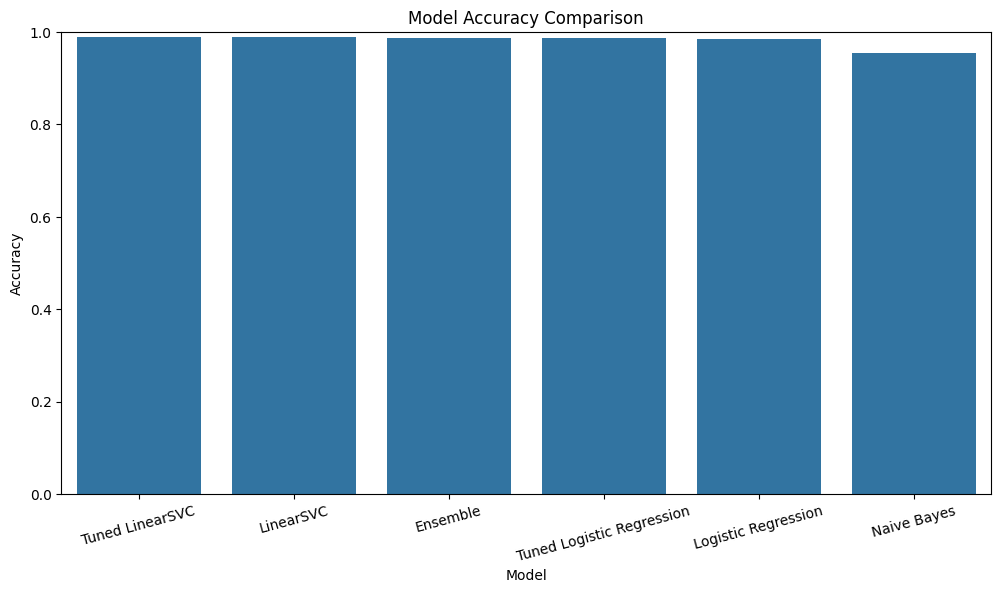

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results
)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.show()

### Confusion Matrix

In [71]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(
        y_true,
        y_pred
    )
    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

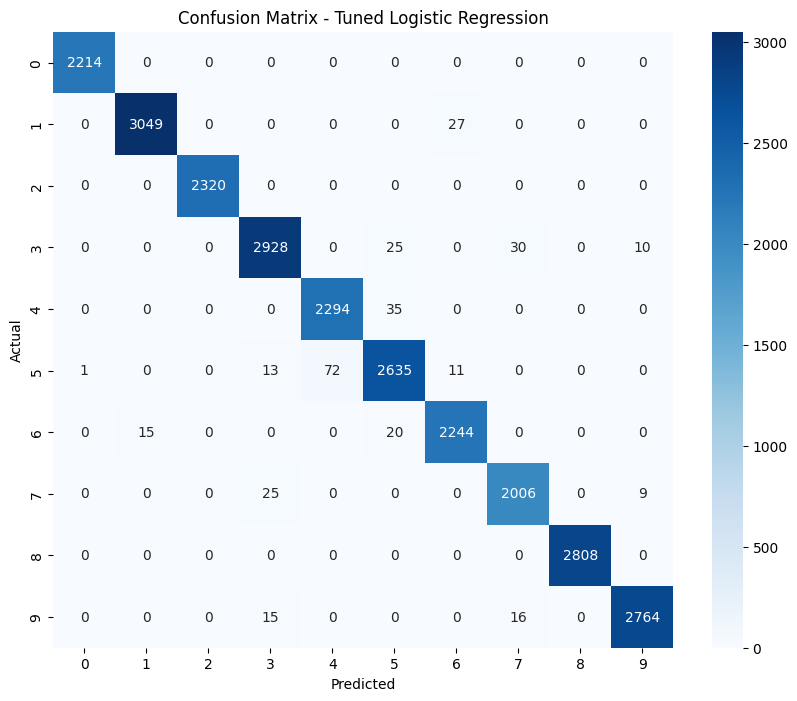

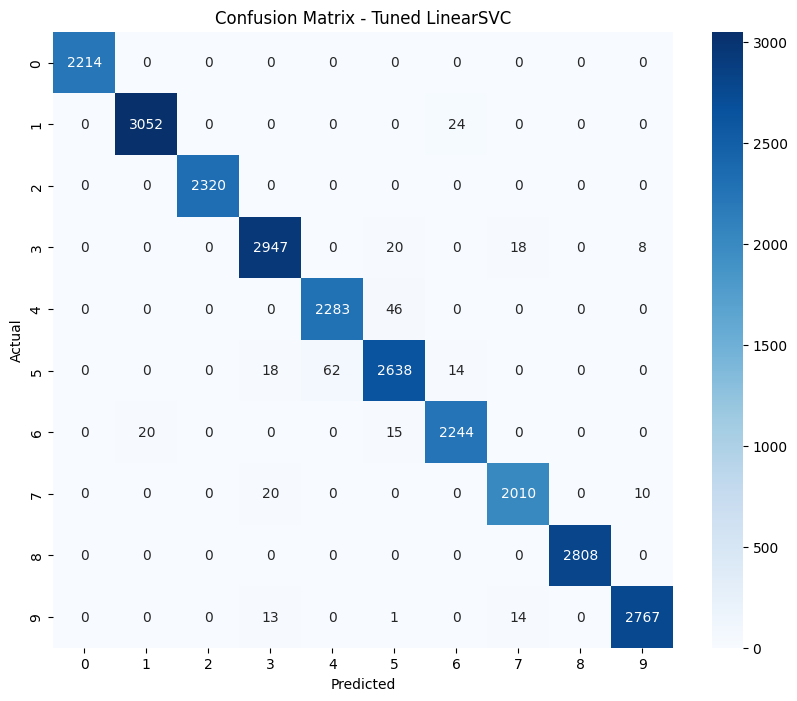

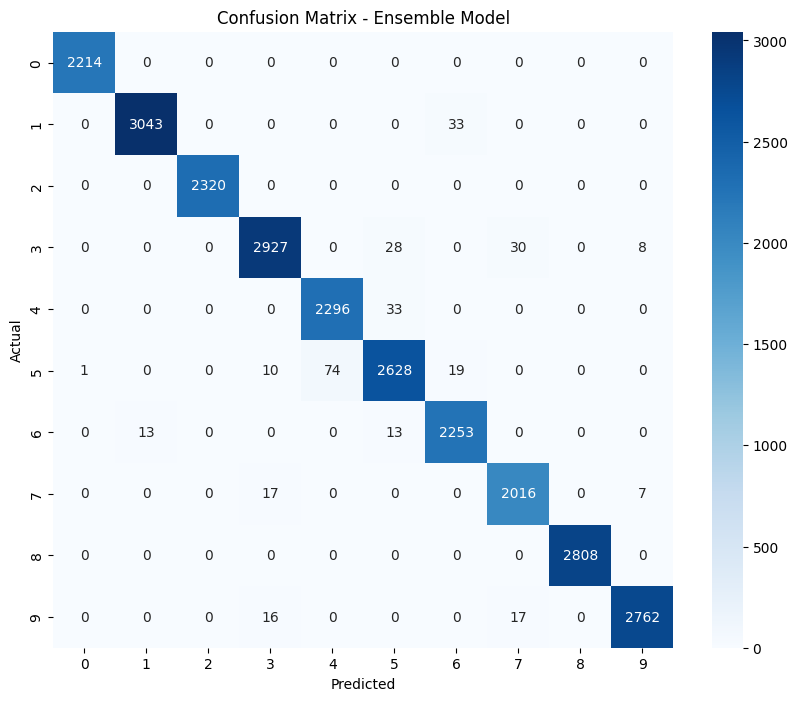

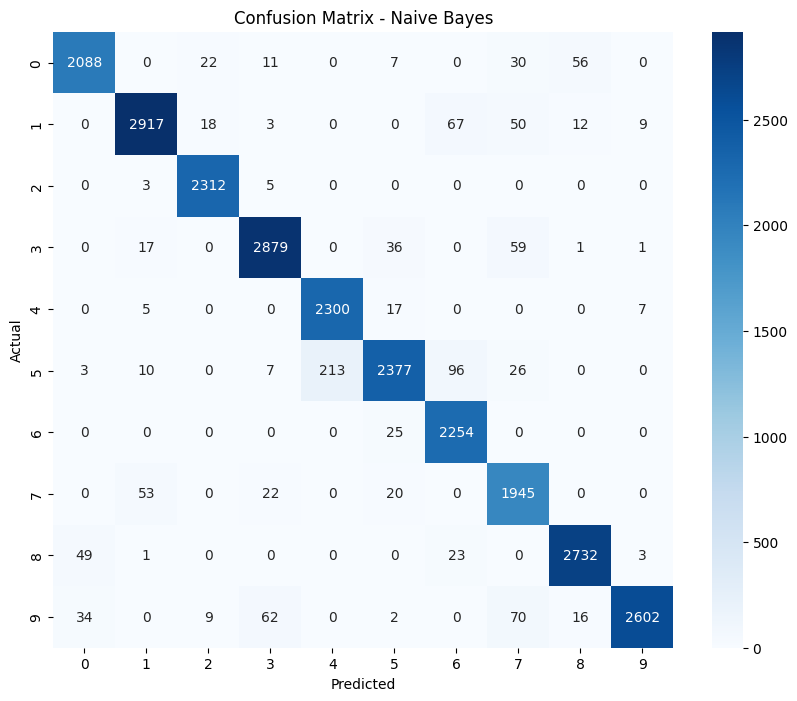

In [72]:
# Logistic Regression Confusion Matrix
plot_confusion_matrix(
    y_test,
    y_pred_best_log,
    "Confusion Matrix - Tuned Logistic Regression"
)

# LinearSVC Confusion Matrix
plot_confusion_matrix(
    y_test,
    y_pred_best_svm,
    "Confusion Matrix - Tuned LinearSVC"
)

# Ensemble Confusion Matrix
plot_confusion_matrix(
    y_test,
    y_pred_ensemble,
    "Confusion Matrix - Ensemble Model"
)

# Naive Bayes Confusion Matrix
plot_confusion_matrix(
    y_test,
    y_pred_nb,
    "Confusion Matrix - Naive Bayes"
)

### Automatically Select Best Model

This makes your notebook scalable for future larger datasets.

#### Create Model Dictionary

In [73]:
model_scores = {

    "Logistic Regression": log_acc,
    "Tuned Logistic Regression": best_log_acc,
    "Naive Bayes": nb_acc,
    # "Random Forest": rf_acc,
    "LinearSVC": svm_acc,
    "Tuned LinearSVC": best_svm_acc,
    "Ensemble": ensemble_acc
}

#### Best Model Selection

Now we combine:

test accuracy
CV accuracy
overfitting penalty
Scoring Formula

FinalScore=(0.5×TestAccuracy)+(0.4×CVAccuracy)−(0.3×Gap)

##### Create Metrics Dictionary

In [74]:
model_metrics = {

    "Logistic Regression": {
        "train_acc": train_accuracy_log,
        "test_acc": log_acc,
        "cv_acc": log_cv_scores.mean()
    },

    "Tuned Logistic Regression": {
        "train_acc": train_accuracy_best_log,
        "test_acc": best_log_acc,
        "cv_acc": log_cv_scores.mean()
    },

    "LinearSVC": {
        "train_acc": train_accuracy_svm,
        "test_acc": svm_acc,
        "cv_acc": svm_cv_scores.mean()
    },

    "Tuned LinearSVC": {
        "train_acc": train_accuracy_best_svm,
        "test_acc": best_svm_acc,
        "cv_acc": svm_cv_scores.mean()
    },

    "Naive Bayes": {
        "train_acc": train_accuracy_nb,
        "test_acc": nb_acc,
        "cv_acc": nb_cv_scores.mean()
    },

    "Ensemble": {
        "train_acc": train_accuracy_ensemble,
        "test_acc": ensemble_acc,
        "cv_acc": ensemble_cv_scores.mean()
    }
}

##### Calculate Overfitting Gap

In [75]:
for model_name, metrics in model_metrics.items():

    gap = abs(
        metrics["train_acc"] - metrics["test_acc"]
    )

    metrics["gap"] = gap

##### Print Model Stability

In [76]:
metrics_df = pd.DataFrame(model_metrics).T.reset_index()

metrics_df = metrics_df.rename(columns={
    'index': 'Model',
    'train_acc': 'Train Accuracy',
    'test_acc': 'Test Accuracy',
    'cv_acc': 'CV Accuracy',
    'gap': 'Overfitting Gap'
})

metrics_df

,Model,Train Accuracy,Test Accuracy,CV Accuracy,Overfitting Gap
0,Logistic Regression,0.989789,0.984601,0.985803,0.005188
1,Tuned Logistic Regression,0.994245,0.987337,0.985803,0.006908
2,LinearSVC,0.996903,0.988040,0.988246,0.008862
3,Tuned LinearSVC,0.999248,0.988158,0.988246,0.011090
4,Naive Bayes,0.958034,0.953881,0.953295,0.004153
5,Ensemble,0.995759,0.987532,0.986516,0.008227


##### Calculate Final Score

In [77]:
for model_name, metrics in model_metrics.items():
    final_score = (
        0.5 * metrics["test_acc"]
        +
        0.4 * metrics["cv_acc"]
        -
        0.3 * metrics["gap"]
    )

    metrics["final_score"] = final_score

##### Select Best Generalizing Model

In [78]:
best_model_name = max(
    model_metrics,
    key=lambda x: model_metrics[x]["final_score"]
)

print("Best Generalizing Model:")
print(best_model_name)

Best Generalizing Model:
LinearSVC


#### Assign Best Model Automatically

In [79]:
if best_model_name == "Logistic Regression":
    best_model = log_model

elif best_model_name == "Tuned Logistic Regression":
    best_model = best_log_model

elif best_model_name == "Naive Bayes":
    best_model = nb_model

# elif best_model_name == "Random Forest":
#     best_model = rf_model

elif best_model_name == "LinearSVC":
    best_model = svm_model

elif best_model_name == "Tuned LinearSVC":
    best_model = best_svm

elif best_model_name == "Ensemble":
    best_model = ensemble_model

### Evaluation Metrics

#### Classification Report

In [80]:
best_predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2214
           1       0.99      0.99      0.99      3076
           2       1.00      1.00      1.00      2320
           3       0.98      0.98      0.98      2993
           4       0.97      0.98      0.98      2329
           5       0.97      0.97      0.97      2732
           6       0.98      0.99      0.99      2279
           7       0.98      0.98      0.98      2040
           8       1.00      1.00      1.00      2808
           9       0.99      0.99      0.99      2795

    accuracy                           0.99     25586
   macro avg       0.99      0.99      0.99     25586
weighted avg       0.99      0.99      0.99     25586



### Error Analysis

Analyze incorrectly classified banking queries.

#### Create Prediction DataFrame

In [81]:
test_df = pd.DataFrame({
    'Question': df.iloc[y_test.index]['Question'].values,
    'Actual': y_test.values,
    'Predicted': best_predictions
})

#### Load Label Encoder

In [82]:
with open("../models/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

#### Decode Labels

In [83]:
test_df['Actual_Label'] = label_encoder.inverse_transform(
    test_df['Actual']
)

test_df['Predicted_Label'] = label_encoder.inverse_transform(
    test_df['Predicted']
)

#### Misclassified Samples

In [84]:
errors = test_df[
    test_df['Actual'] != test_df['Predicted']
]

print("Total Misclassified Samples:", len(errors))

Total Misclassified Samples: 306


In [85]:
# View Errors
errors.sample(10)

,Question,Actual,Predicted,Actual_Label,Predicted_Label
22126,How does What is an IPO work? #23939,4,5,Financial Markets,General Finance
19038,Explain the concept of What is term insurance....,5,6,General Finance,Insurance & Govt Schemes
3628,Why do customers need What is Nifty 50? #79946,5,4,General Finance,Financial Markets
8241,Please explain what is a demat account,5,3,General Finance,Digital Banking
8246,What role does What is a Sovereign Gold Bond p...,5,3,General Finance,Digital Banking
10779,How can customers use What is the PMJJBY schem...,1,6,Basic Accounts,Insurance & Govt Schemes
24432,What do you mean by What is a remittance? #77569,3,7,Digital Banking,International Banking
3108,What role does What is an IPO play in banking?...,4,5,Financial Markets,General Finance
6833,Tell me about What is a wire transfer. #93261,3,7,Digital Banking,International Banking
1060,Tell me about What is DICGC insurance. #48506,1,6,Basic Accounts,Insurance & Govt Schemes


### Save Best Model

In [86]:
with open("../models/best_intent_classifier.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Best model saved successfully!")

Best model saved successfully!


### Prediction Pipeline

This reusable pipeline will later integrate into:

- Streamlit chatbot
- RAG system

#### Load Vectorizers

In [87]:
with open("../models/word_vectorizer.pkl", "rb") as f:
    word_vectorizer = pickle.load(f)

with open("../models/char_vectorizer.pkl", "rb") as f:
    char_vectorizer = pickle.load(f)

#### Load model

In [91]:
with open("../models/best_intent_classifier.pkl", "rb") as f:
    best_model = pickle.load(f)

#### Load label encoder

In [92]:
with open("../models/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

#### Text Preprocessing Function

In [93]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

#### Create Prediction Pipeline

In [94]:
from scipy.sparse import hstack

def predict_intent(query):

    # preprocess
    cleaned_query = preprocess_text(query)

    # word features
    word_features = word_vectorizer.transform(
        [cleaned_query]
    )

    # char features
    char_features = char_vectorizer.transform(
        [cleaned_query]
    )

    # combine features
    combined_features = hstack([
        word_features,
        char_features
    ])

    # predict
    prediction = best_model.predict(
        combined_features
    )

    # decode prediction
    predicted_label = label_encoder.inverse_transform(
        prediction
    )[0]

    return predicted_label

### Test Prediction Pipeline

In [95]:
queries = [
    "How to activate UPI?",
    "How can I block my debit card?",
    "What is SWIFT transfer?",
    "Explain mutual funds",
    "What is home loan EMI?"
]

for query in queries:
    prediction = predict_intent(query)
    print(f"Query: {query}")
    print(f"Predicted Intent: {prediction}")
    print("-"*60)

Query: How to activate UPI?
Predicted Intent: Customer Service
------------------------------------------------------------
Query: How can I block my debit card?
Predicted Intent: Customer Service
------------------------------------------------------------
Query: What is SWIFT transfer?
Predicted Intent: International Banking
------------------------------------------------------------
Query: Explain mutual funds
Predicted Intent: General Finance
------------------------------------------------------------
Query: What is home loan EMI?
Predicted Intent: Loans & Interest
------------------------------------------------------------


# Key Insights & Observations

## 1. Intent Classification Objective

The primary objective of this notebook was to build a robust NLP-based intent classification system for banking FAQs.

The system was designed to:
- identify banking-related intents
- classify customer queries into predefined categories
- support chatbot and RAG-based applications

The intent classification pipeline transforms natural language banking questions into structured intent labels.

---

## 2. Feature Engineering Strategy

A hybrid TF-IDF feature engineering approach was implemented using:

### Word-Level TF-IDF
- Captured semantic meaning of banking terms
- Used:
  - unigrams
  - bigrams
  - trigrams

### Character-Level TF-IDF
- Captured spelling patterns and abbreviations
- Improved robustness against:
  - typos
  - partial words
  - user input variations

### Combined Sparse Representation
- Word and character features were merged using:
  - `hstack()`

This significantly improved contextual understanding and classification performance.

---

## 3. Machine Learning Models Evaluated

Multiple machine learning algorithms were trained and evaluated:

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline linear classifier |
| Naive Bayes | Fast probabilistic baseline |
| Random Forest | Tree-based ensemble approach |
| LinearSVC | High-dimensional sparse text classification |
| Voting Ensemble | Combined prediction strategy |

---

## 4. Logistic Regression Performance

### Observation
- Logistic Regression produced stable and interpretable results.
- Performed well on sparse TF-IDF vectors.

### Strengths
- Fast training
- Good baseline performance
- Handles multiclass classification effectively

### Hyperparameter Tuning
GridSearchCV was applied using:
- different `C` values
- balanced class weights

This improved:
- generalization
- test accuracy
- cross-validation stability

---

## 5. Naive Bayes Performance

### Observation
- Multinomial Naive Bayes trained extremely fast.
- Worked reasonably well for frequency-based text features.

### Limitation
- Lower accuracy compared to LinearSVC.
- Assumes feature independence, which is unrealistic for contextual banking phrases.

### Practical Insight
Naive Bayes serves as:
- a strong baseline model
- a lightweight production option for fast inference systems

---

## 6. Random Forest Performance

### Observation
- Random Forest produced comparatively lower accuracy on TF-IDF sparse vectors.

### Reason
Tree-based models struggle with:
- high-dimensional sparse matrices
- extremely sparse NLP features

### Insight
Random Forest is more suitable for:
- structured/tabular datasets
- numerical feature spaces

rather than large sparse NLP vectors.

---

## 7. LinearSVC Performance

### Best Performing Model

LinearSVC achieved the strongest overall performance among all classical ML models.

### Why It Performed Best
LinearSVC is highly optimized for:
- sparse TF-IDF matrices
- high-dimensional feature spaces
- text classification tasks

### Key Advantages
- high scalability
- fast inference
- strong generalization capability
- excellent handling of sparse vectors

### Hyperparameter Tuning
GridSearchCV tuning included:
- multiple `C` values
- class balancing
- increased iteration limits

This improved:
- convergence
- classification accuracy
- model stability

---

## 8. Ensemble Model Performance

### Voting Classifier
An ensemble model was created using:
- Logistic Regression
- Naive Bayes
- LinearSVC

### Observation
- Ensemble learning improved prediction robustness.
- Combined multiple learning patterns into a unified prediction system.

### Limitation
- Accuracy improvement was moderate because LinearSVC already dominated performance.

---

## 9. Cross Validation Analysis

5-fold cross-validation was applied for:
- Logistic Regression
- LinearSVC
- Ensemble Model

### Observation
- Cross-validation scores remained close to testing accuracy.
- Indicates:
  - stable learning
  - good generalization
  - reduced variance

This confirms that the trained models are not heavily overfitting.

---

## 10. Overfitting Analysis

Training and testing accuracies were compared across all models.

### Observation
- Small train-test gaps indicate controlled overfitting.
- Balanced class weighting improved minority-class learning.

### Insight
The models generalized effectively to unseen banking queries.

---

## 11. Real-Time Prediction Pipeline

A reusable prediction pipeline was implemented using:
- text preprocessing
- word TF-IDF transformation
- character TF-IDF transformation
- sparse feature combination
- label decoding

### Prediction Workflow
1. Clean incoming query
2. Generate word-level TF-IDF features
3. Generate character-level TF-IDF features
4. Combine sparse vectors
5. Predict intent label
6. Decode original category

This architecture supports:
- APIs
- chatbot systems
- production inference pipelines

---

## 12. Model Persistence

The following components were saved using `pickle`:
- trained models
- vectorizers
- label encoder

This enables:
- deployment readiness
- model reusability
- scalable inference systems

---

## 13. Overall Conclusion

- Hybrid TF-IDF feature engineering significantly improved NLP representation quality.
- LinearSVC emerged as the strongest traditional machine learning model for banking intent classification.
- Ensemble learning improved robustness, though LinearSVC remained dominant.
- The complete architecture is suitable for:
  - banking chatbots
  - FAQ automation
  - customer support AI
  - semantic routing systems
  - Retrieval-Augmented Generation (RAG) applications

The notebook successfully demonstrates an end-to-end classical NLP intent classification pipeline optimized for large-scale banking FAQ systems.